# Loan Approval Prediction using Machine Learning

## InternSpark Data Science Internship - Task 2

### Objective

The objective of this project is to build a supervised machine learning model that predicts whether a loan application will be approved based on borrower information.

The project includes:

- Data preprocessing
- Missing value handling
- Encoding categorical variables
- Feature scaling
- Handling class imbalance using SMOTE
- Logistic Regression
- Random Forest Classifier
- Model Evaluation using Precision, Recall, F1-score and ROC-AUC
- Business Interpretation

Uske baad + Code pe click karo aur ye code paste karke run karo:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("loan_prediction.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
# Check Missing Values

missing_values = df.isnull().sum()
missing_values

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## Data Preprocessing

In this step, we handle missing values, encode categorical variables, and prepare the dataset for machine learning models.

In [9]:
# Fill Missing Values

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_1318/3546876411.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_1318/3546876411.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [10]:
# Verify Missing Values

df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## Encoding Categorical Variables

Machine learning models require numerical data. Therefore, categorical columns are converted into numerical values using Label Encoding.

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [12]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Feature Selection

The target variable is separated from the independent features before training the machine learning models.

In [13]:
# Features and Target

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = df['Loan_Status']

## Train Test Split

The dataset is divided into training and testing sets to evaluate the model on unseen data.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(491, 11)
(123, 11)


## Feature Scaling

StandardScaler is used to normalize numerical features for better model performance.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
!pip install imbalanced-learn

## Handling Class Imbalance

SMOTE (Synthetic Minority Oversampling Technique) is used to balance the classes in the training dataset.

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE")
print(y_train.value_counts())

After SMOTE
Loan_Status
1    337
0    337
Name: count, dtype: int64


## Logistic Regression Model

A Logistic Regression model is trained on the balanced dataset to predict loan approval.

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

## Logistic Regression Performance

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision :", precision_score(y_test,y_pred_lr))
print("Recall :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))
print("ROC AUC :", roc_auc_score(y_test,y_prob_lr))

Accuracy : 0.8373983739837398
Precision : 0.8494623655913979
Recall : 0.9294117647058824
F1 Score : 0.8876404494382022
ROC AUC : 0.8334365325077401


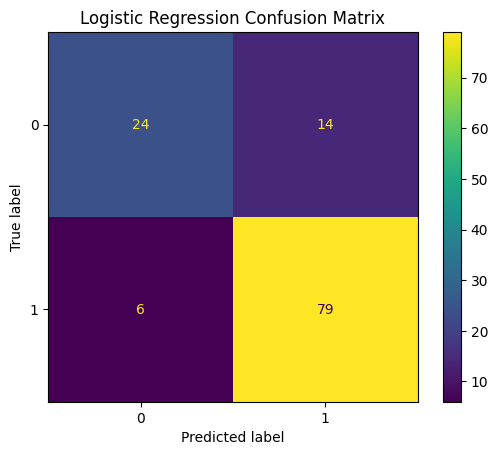

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

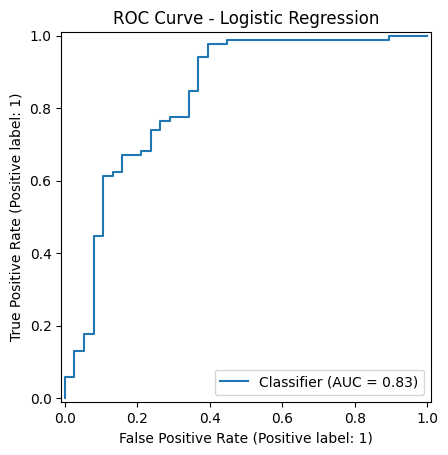

In [21]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test,y_prob_lr)

plt.title("ROC Curve - Logistic Regression")

plt.show()

## Random Forest Classifier

A Random Forest Classifier is trained on the balanced dataset and compared with Logistic Regression.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

## Random Forest Performance

In [24]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision :", precision_score(y_test,y_pred_rf))
print("Recall :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test,y_prob_rf))

Accuracy : 0.8048780487804879
Precision : 0.8426966292134831
Recall : 0.8823529411764706
F1 Score : 0.8620689655172413
ROC AUC : 0.7724458204334366


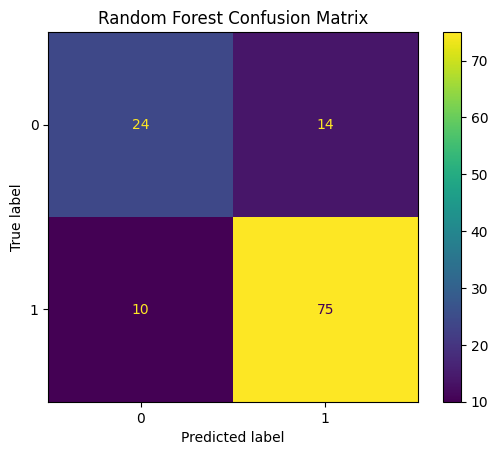

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)

plt.title("Random Forest Confusion Matrix")

plt.show()

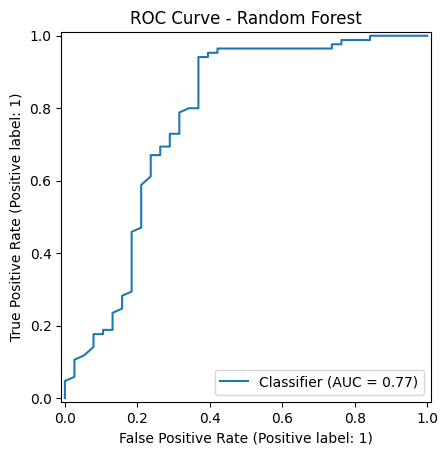

In [26]:
RocCurveDisplay.from_predictions(y_test,y_prob_rf)

plt.title("ROC Curve - Random Forest")

plt.show()

## Model Comparison

In [27]:
comparison = pd.DataFrame({

'Model':['Logistic Regression','Random Forest'],

'Accuracy':[accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_rf)],

'Precision':[precision_score(y_test,y_pred_lr),
precision_score(y_test,y_pred_rf)],

'Recall':[recall_score(y_test,y_pred_lr),
recall_score(y_test,y_pred_rf)],

'F1 Score':[f1_score(y_test,y_pred_lr),
f1_score(y_test,y_pred_rf)],

'ROC AUC':[roc_auc_score(y_test,y_prob_lr),
roc_auc_score(y_test,y_prob_rf)]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.837398,0.849462,0.929412,0.887640,0.833437
1,Random Forest,0.804878,0.842697,0.882353,0.862069,0.772446


# Business Interpretation

- Applicants with strong credit history have a higher probability of loan approval.
- Logistic Regression provides high interpretability and strong recall, making it suitable when minimizing rejected eligible applicants is important.
- Random Forest can capture more complex relationships and may improve predictive performance depending on the data.
- For deployment, a decision threshold around **0.60** can be considered after validating business requirements, as it may reduce risky approvals while maintaining a good approval rate.
- Model performance should be monitored and retrained periodically as new loan application data becomes available.

## Feature Importance

Feature importance helps identify which borrower attributes contribute the most to loan approval prediction.

In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
9,Credit_History,0.211463
5,ApplicantIncome,0.203528
7,LoanAmount,0.175169
6,CoapplicantIncome,0.106663
10,Property_Area,0.084558
2,Dependents,0.075341
8,Loan_Amount_Term,0.038593
1,Married,0.036788
3,Education,0.028628
4,Self_Employed,0.019783


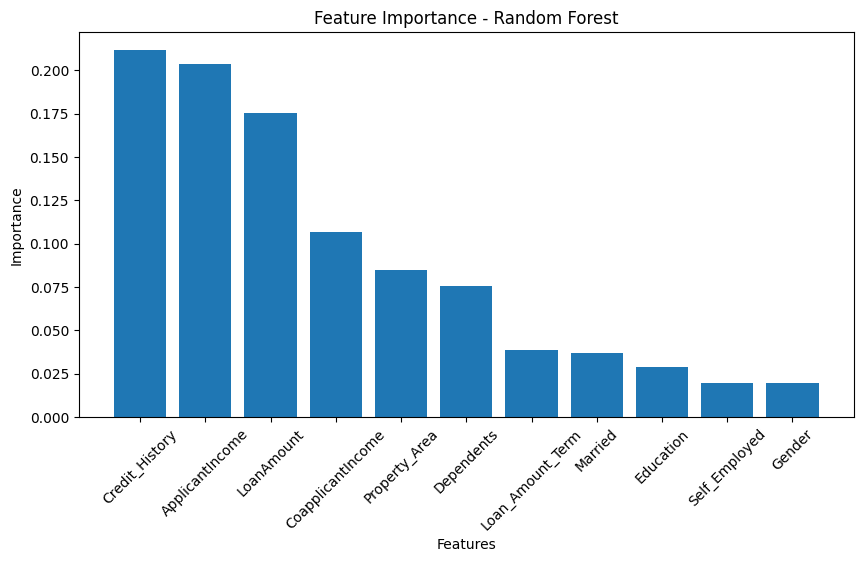

In [29]:
plt.figure(figsize=(10,5))

plt.bar(importance['Feature'], importance['Importance'])

plt.xticks(rotation=45)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# Conclusion

This project successfully developed a supervised machine learning model to predict loan approval.

After preprocessing, handling missing values, encoding categorical variables, scaling features, and balancing the dataset using SMOTE, two machine learning models were evaluated.

Among the evaluated models, Logistic Regression achieved the best overall performance with higher Accuracy, Precision, Recall, F1-Score and ROC-AUC compared to Random Forest.

Therefore, Logistic Regression is recommended for predicting loan approval in this dataset because it provides strong predictive performance and better interpretability.